
 ANÁLISIS DE PRECIOS RECIENTES INTRADÍA (ÚLTIMOS REGISTROS DE LOS ÚLTIMOS 7 DÍAS) 
Esta sección verifica el precio real de cierre de cada jornada reciente.

-------------------------------------------------------------------------------------
      ÚLTIMOS 10 PRECIOS REGISTRADOS PARA EL DÍA: 2025-10-28      
-------------------------------------------------------------------------------------
Fecha y Hora              | Apertura   | Máximo     | Mínimo     | Cierre    
---------------------------------------------------------------------------
2025-10-28 07:30:00       | 3.3832     | 3.3832     | 3.3830     | 3.3830
2025-10-28 07:45:00       | 3.3830     | 3.3830     | 3.3824     | 3.3825
2025-10-28 08:15:00       | 3.3837     | 3.3837     | 3.3837     | 3.3837
2025-10-28 08:45:00       | 3.3837     | 3.3837     | 3.3837     | 3.3837
2025-10-28 09:00:00       | 3.3828     | 3.3828     | 3.3747     | 3.3761
2025-10-28 09:15:00       | 3.3769     | 3.3878     | 3.3769     | 3.3877
2025-

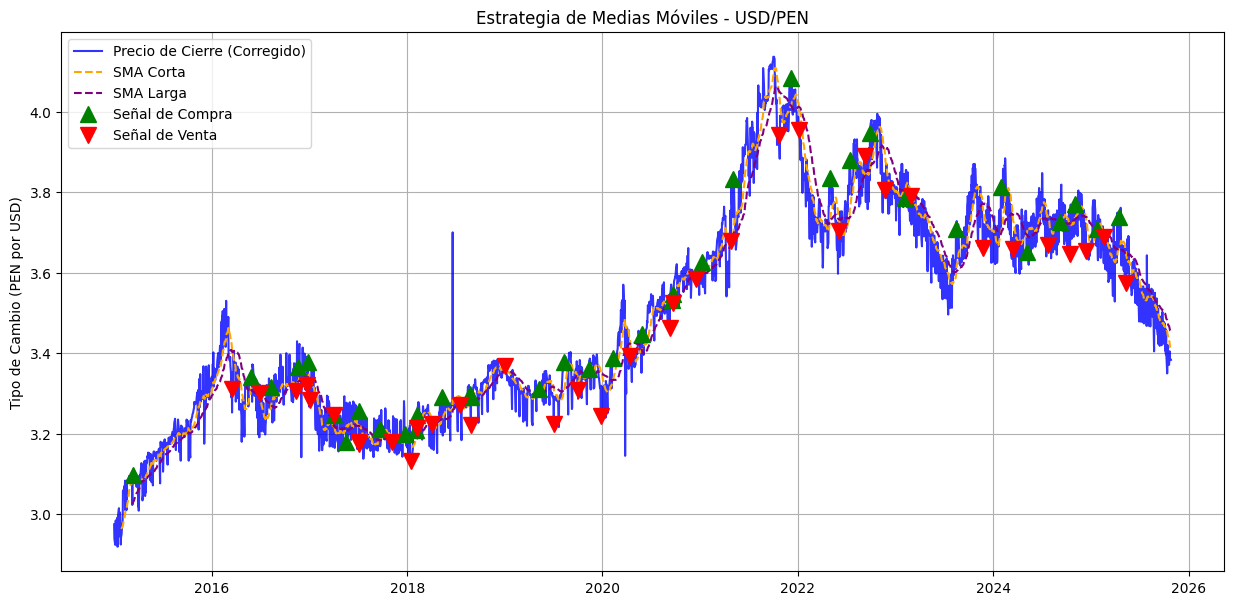

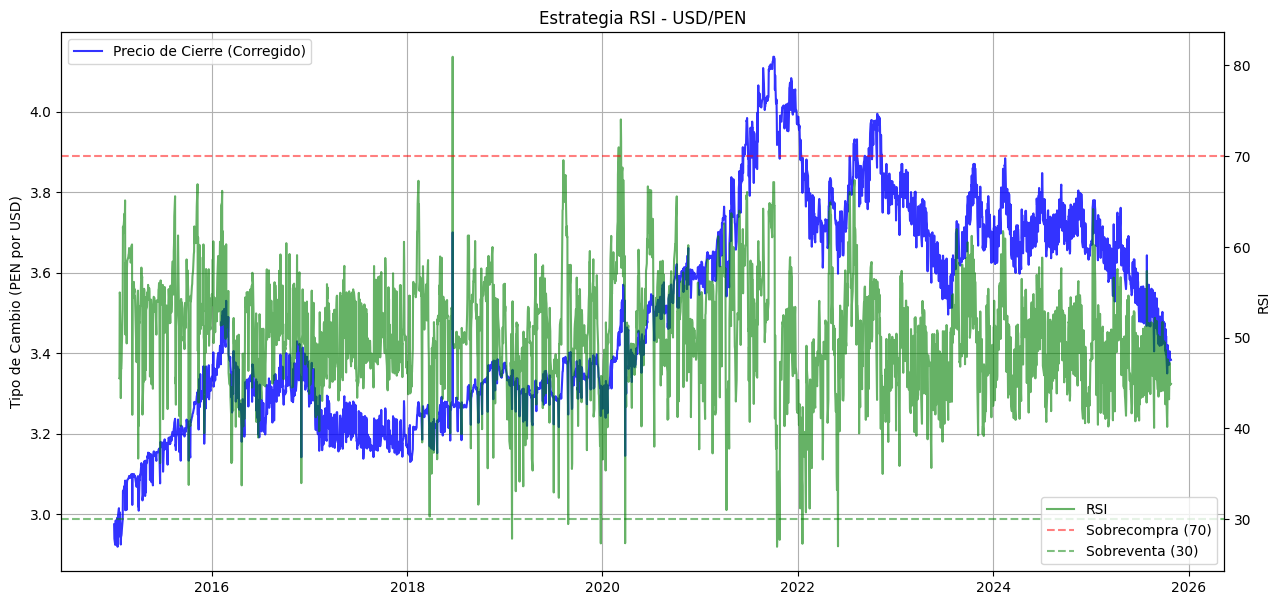

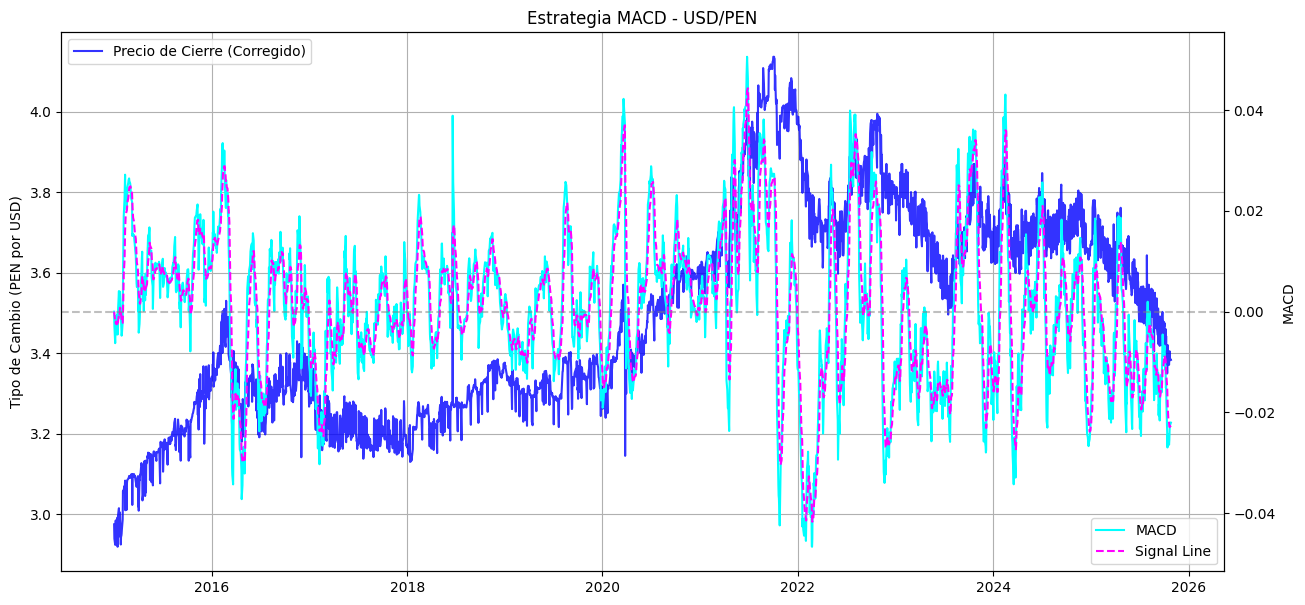

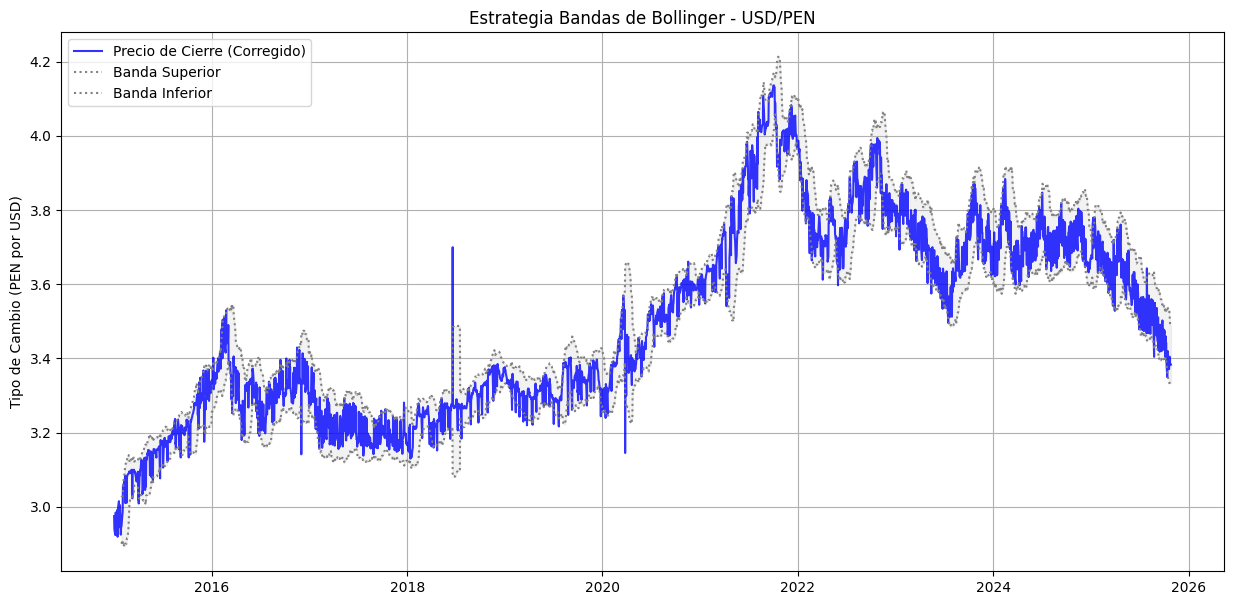


       RESUMEN DE SEÑALES Y RECOMENDACIÓN FINAL (DATOS DIARIOS)
Análisis para el día de cierre consolidado: 2025-10-27
Precio de Cierre de Referencia (Verificado): 3.3833 S/ por USD

Indicador                 Estado Actual                            Señal          
--------------------------------------------------------------------------------
Medias Móviles            Bajista (SMA Corta < SMA Larga)          VENTA          
RSI                       Neutral (RSI=44.91)                      NEUTRAL        
MACD                      Cruce Alcista (MACD > Signal)            COMPRA         
Bandas de Bollinger       Precio dentro de las bandas              NEUTRAL        
--------------------------------------------------------------------------------

Puntaje Consolidado: 0.5
RECOMENDACIÓN FINAL: NEUTRAL / MANTENER

**ADVERTENCIA:** Este es un análisis técnico y no constituye asesoramiento financiero.


Realizando pronóstico ARIMA con modelo fijo (5,1,0) para 30 días...

Pronóstico par

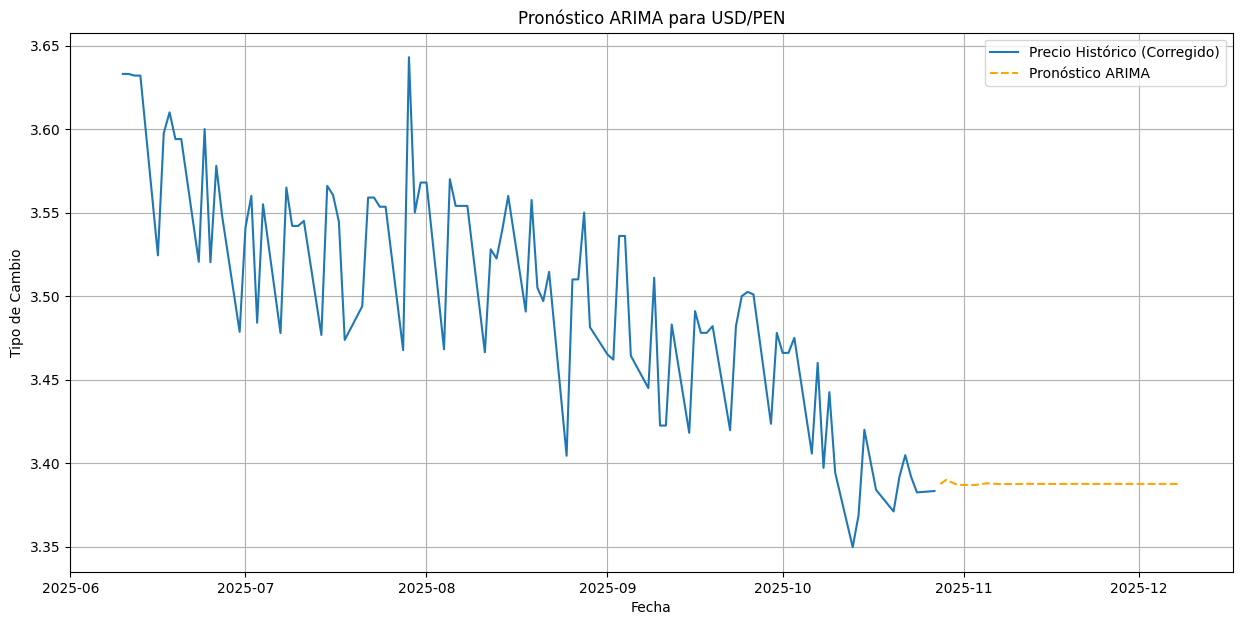


--- Iniciando Microanálisis Intradía para PEN=X (intervalo: 5m) ---

               ANÁLISIS INTRADÍA (TIEMPO REAL APROX.)
Último precio registrado: 3.3927 S/ por USD

Indicador                 Señal Detectada          
--------------------------------------------------
Medias Móviles            VENTA                    
RSI                       VENTA                    
MACD                      COMPRA                   
Bandas de Bollinger       NEUTRAL                  
--------------------------------------------------

Puntaje Consolidado: -0.5
RECOMENDACIÓN INTRADÍA: VENTA DÉBIL


In [4]:
# --- LIBRERÍAS NECESARIAS ---
# pip install yfinance pandas matplotlib statsmodels

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
from datetime import date, timedelta

# --- CONFIGURACIÓN GLOBAL ---
warnings.filterwarnings("ignore")

def mostrar_y_obtener_cierres_correctos(ticker="PEN=X"):
    """
    Descarga y muestra los precios intradía y DEVUELVE una Serie con los precios de
    cierre precisos y verificados para la corrección posterior.
    """
    print("\n" + "="*85)
    print(" ANÁLISIS DE PRECIOS RECIENTES INTRADÍA (ÚLTIMOS REGISTROS DE LOS ÚLTIMOS 7 DÍAS) ")
    print("="*85)
    print("Esta sección verifica el precio real de cierre de cada jornada reciente.")

    try:
        end_date_req = date.today() + timedelta(days=1)
        start_date_req = end_date_req - timedelta(days=8)

        data_intradia = yf.download(
            tickers=ticker, start=start_date_req, end=end_date_req,
            interval="15m", progress=False, auto_adjust=False
        )

        if data_intradia.empty:
            print("No se encontraron datos intradía para los últimos 7 días.")
            return None

        if isinstance(data_intradia.columns, pd.MultiIndex):
            data_intradia.columns = data_intradia.columns.get_level_values(0)

        data_intradia.index = data_intradia.index.tz_convert('America/Lima')
        unique_dates = data_intradia.index.normalize().unique().sort_values(ascending=False)
        cierres_diarios_correctos = {}

        for trade_date in unique_dates:
            print("\n" + "-" * 85)
            print(f"      ÚLTIMOS 10 PRECIOS REGISTRADOS PARA EL DÍA: {trade_date.strftime('%Y-%m-%d')}      ")
            print("-" * 85)
            day_data = data_intradia[data_intradia.index.date == trade_date.date()]
            if day_data.empty: continue
            ultimos_10_del_dia = day_data.tail(10)
            print(f"{'Fecha y Hora':<25} | {'Apertura':<10} | {'Máximo':<10} | {'Mínimo':<10} | {'Cierre':<10}")
            print("-" * 75)
            for index, row in ultimos_10_del_dia.iterrows():
                linea = (f"{index.strftime('%Y-%m-%d %H:%M:%S'):<25} | "
                         f"{row['Open']:.4f}     | {row['High']:.4f}     | "
                         f"{row['Low']:.4f}     | {row['Close']:.4f}")
                if index == ultimos_10_del_dia.index[-1]:
                    print(f"{linea}  <-- CIERRE DEL MERCADO PARA ESTE DÍA")
                    cierres_diarios_correctos[trade_date] = row['Close']
                else:
                    print(linea)
            print("-" * 75)
        print("\n" + "="*85 + "\n")
        return pd.Series(cierres_diarios_correctos)
    except Exception as e:
        print(f"Ocurrió un error al obtener los datos intradía: {e}")
        return None

def get_forex_data(ticker, start_date, end_date):
    """Obtiene datos históricos diarios."""
    try:
        data = yf.download(ticker, start=start_date, end=end_date, progress=False)
        return data if not data.empty else None
    except Exception as e:
        print(f"Error al obtener datos para {ticker}: {e}")
        return None

# --- ESTRATEGIAS DE ANÁLISIS TÉCNICO ---
def moving_average_strategy(data, short_window=20, long_window=50):
    df = data.copy()
    close_prices = df['Close'].iloc[:, 0] if isinstance(df['Close'], pd.DataFrame) else df['Close']
    df['SMA_Short'] = close_prices.rolling(window=short_window).mean()
    df['SMA_Long'] = close_prices.rolling(window=long_window).mean()
    df['Signal'] = 0
    df.loc[df.index[short_window:], 'Signal'] = (df['SMA_Short'] > df['SMA_Long']).astype(int) * 2 - 1
    df['Position'] = df['Signal'].diff()
    return df

def rsi_strategy(data, window=14, buy_threshold=30, sell_threshold=70):
    df = data.copy()
    close_prices = df['Close'].iloc[:, 0] if isinstance(df['Close'], pd.DataFrame) else df['Close']
    delta = close_prices.diff(1)
    gain = delta.where(delta > 0, 0); loss = -delta.where(delta < 0, 0)
    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    df['Signal'] = 0; df.loc[df['RSI'] < buy_threshold, 'Signal'] = 1; df.loc[df['RSI'] > sell_threshold, 'Signal'] = -1
    return df

def macd_strategy(data, short_window=12, long_window=26, signal_window=9):
    df = data.copy()
    close_prices = df['Close'].iloc[:, 0] if isinstance(df['Close'], pd.DataFrame) else df['Close']
    ema_short = close_prices.ewm(span=short_window, adjust=False).mean()
    ema_long = close_prices.ewm(span=long_window, adjust=False).mean()
    df['MACD'] = ema_short - ema_long
    df['Signal_Line'] = df['MACD'].ewm(span=signal_window, adjust=False).mean()
    df['Signal'] = 0; df.loc[df['MACD'] > df['Signal_Line'], 'Signal'] = 1; df.loc[df['MACD'] < df['Signal_Line'], 'Signal'] = -1
    return df

def bollinger_bands_strategy(data, window=20, num_std_dev=2):
    df = data.copy()
    close_prices = df['Close'].iloc[:, 0] if isinstance(df['Close'], pd.DataFrame) else df['Close']
    df['SMA_Mid'] = close_prices.rolling(window=window).mean()
    std_dev = close_prices.rolling(window=window).std()
    df['Upper_Band'] = df['SMA_Mid'] + (std_dev * num_std_dev)
    df['Lower_Band'] = df['SMA_Mid'] - (std_dev * num_std_dev)
    df['Signal'] = 0; df.loc[close_prices < df['Lower_Band'], 'Signal'] = 1; df.loc[close_prices > df['Upper_Band'], 'Signal'] = -1
    return df

def perform_arima_forecast(data, periods=30):
    series = data['Close'].iloc[:, 0] if isinstance(data['Close'], pd.DataFrame) else data['Close']
    series = series.dropna()
    if series.empty: return None, None
    print(f"\nRealizando pronóstico ARIMA con modelo fijo (5,1,0) para {periods} días...")
    try:
        model = ARIMA(series, order=(5, 1, 0)); model_fit = model.fit()
        forecast = model_fit.get_forecast(steps=periods).predicted_mean
        last_date = series.index[-1]
        forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=periods, freq='B')
        forecast_series = pd.Series(forecast.values, index=forecast_index)
        print(f"\nPronóstico para los próximos {periods} días hábiles:"); print(forecast_series)
        return forecast_series, series
    except Exception as e:
        print(f"Error durante el pronóstico ARIMA: {e}"); return None, None

def plot_strategy(df, title, forex_data_plot):
    """
    Función de ploteo robusta que dibuja los indicadores correctos
    basándose en las columnas presentes en el DataFrame de entrada.
    """
    if df.empty: return
    fig, ax1 = plt.subplots(figsize=(15, 7))
    close_prices_to_plot = forex_data_plot['Close']
    if isinstance(close_prices_to_plot, pd.DataFrame):
        close_prices_to_plot = close_prices_to_plot.iloc[:, 0]
    
    ax1.plot(close_prices_to_plot.index, close_prices_to_plot.values, label='Precio de Cierre (Corregido)', color='blue', alpha=0.8)

    # Lógica para Medias Móviles
    if 'SMA_Short' in df.columns and 'SMA_Long' in df.columns:
        ax1.plot(df['SMA_Short'], label='SMA Corta', color='orange', linestyle='--')
        ax1.plot(df['SMA_Long'], label='SMA Larga', color='purple', linestyle='--')
        buy_signals = df[df['Position'] == 2]
        sell_signals = df[df['Position'] == -2]
        ax1.plot(buy_signals.index, close_prices_to_plot.loc[buy_signals.index], '^', markersize=12, color='green', label='Señal de Compra')
        ax1.plot(sell_signals.index, close_prices_to_plot.loc[sell_signals.index], 'v', markersize=12, color='red', label='Señal de Venta')

    # Lógica para Bandas de Bollinger
    if 'Upper_Band' in df.columns:
        ax1.plot(df['Upper_Band'], label='Banda Superior', color='gray', linestyle=':')
        ax1.plot(df['Lower_Band'], label='Banda Inferior', color='gray', linestyle=':')
        ax1.fill_between(df.index, df['Lower_Band'], df['Upper_Band'], color='gray', alpha=0.1)

    ax1.set_ylabel('Tipo de Cambio (PEN por USD)')
    ax1.set_title(title)
    ax1.legend(loc='upper left')
    ax1.grid(True)

    # Lógica para RSI en un eje secundario
    if 'RSI' in df.columns:
        ax2 = ax1.twinx()
        ax2.plot(df['RSI'], label='RSI', color='green', alpha=0.6)
        ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Sobrecompra (70)')
        ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Sobreventa (30)')
        ax2.set_ylabel('RSI')
        ax2.legend(loc='lower right')

    # Lógica para MACD en un eje secundario
    if 'MACD' in df.columns and 'Signal_Line' in df.columns:
        ax2 = ax1.twinx()
        ax2.plot(df['MACD'], label='MACD', color='cyan')
        ax2.plot(df['Signal_Line'], label='Signal Line', color='magenta', linestyle='--')
        ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax2.set_ylabel('MACD')
        ax2.legend(loc='lower right')

    plt.show()

def plot_arima_forecast(original_series, forecast_series, title):
    if original_series is None or forecast_series is None: return
    plt.figure(figsize=(15, 7))
    plt.plot(original_series.index[-100:], original_series.iloc[-100:], label='Precio Histórico (Corregido)')
    plt.plot(forecast_series.index, forecast_series, label=f'Pronóstico ARIMA', color='orange', linestyle='--')
    plt.title(title); plt.xlabel('Fecha'); plt.ylabel('Tipo de Cambio'); plt.legend(); plt.grid(True)
    plt.show()

def generate_final_recommendation(strategies_data, forex_data):
    print("\n" + "="*65); print("       RESUMEN DE SEÑALES Y RECOMENDACIÓN FINAL (DATOS DIARIOS)"); print("="*65)
    close_prices = forex_data['Close'].iloc[:,0] if isinstance(forex_data['Close'], pd.DataFrame) else forex_data['Close']
    analysis_index = -2 if (forex_data.index[-1].date() == date.today()) and len(forex_data) > 1 else -1
    analysis_date = forex_data.index[analysis_index]
    close_price_val = float(close_prices.iloc[analysis_index])
    recommendations = {}; total_score = 0
    for name, df in strategies_data.items():
        if df.empty or 'Signal' not in df.columns: continue
        last_signal = df['Signal'].iloc[analysis_index]
        if name == 'Medias Móviles':
            if last_signal == 1: status, signal, score = "Alcista (SMA Corta > SMA Larga)", "COMPRA", 1
            elif last_signal == -1: status, signal, score = "Bajista (SMA Corta < SMA Larga)", "VENTA", -1
            else: status, signal, score = "Indefinido", "NEUTRAL", 0
        elif name == 'RSI':
            last_rsi_val = df['RSI'].iloc[analysis_index]
            if pd.isna(last_rsi_val): status, signal, score = "Calculando...", "NEUTRAL", 0
            elif last_signal == 1: status, signal, score = f"Sobrevendido (RSI={last_rsi_val:.2f})", "COMPRA", 1
            elif last_signal == -1: status, signal, score = f"Sobrecomprado (RSI={last_rsi_val:.2f})", "VENTA", -1
            else: status, signal, score = f"Neutral (RSI={last_rsi_val:.2f})", "NEUTRAL", 0
        elif name == 'MACD':
            if last_signal == 1: status, signal, score = "Cruce Alcista (MACD > Signal)", "COMPRA", 1.5
            elif last_signal == -1: status, signal, score = "Cruce Bajista (MACD < Signal)", "VENTA", -1.5
            else: status, signal, score = "Sin cruce claro", "NEUTRAL", 0
        elif name == 'Bandas de Bollinger':
            if last_signal == 1: status, signal, score = "Precio cerca de Banda Inferior", "COMPRA", 1
            elif last_signal == -1: status, signal, score = "Precio cerca de Banda Superior", "VENTA", -1
            else: status, signal, score = "Precio dentro de las bandas", "NEUTRAL", 0
        total_score += score; recommendations[name] = (status, signal)
    print(f"Análisis para el día de cierre consolidado: {analysis_date.strftime('%Y-%m-%d')}")
    print(f"Precio de Cierre de Referencia (Verificado): {close_price_val:.4f} S/ por USD\n")
    print(f"{'Indicador':<25} {'Estado Actual':<40} {'Señal':<15}"); print("-"*80)
    for name, (status, signal) in recommendations.items(): print(f"{name:<25} {status:<40} {signal:<15}")
    print("-"*80)
    if total_score >= 2.5: final_decision = "COMPRA FUERTE"
    elif total_score >= 1: final_decision = "COMPRA"
    elif total_score <= -2.5: final_decision = "VENTA FUERTE"
    elif total_score <= -1: final_decision = "VENTA"
    else: final_decision = "NEUTRAL / MANTENER"
    print(f"\nPuntaje Consolidado: {total_score}"); print(f"RECOMENDACIÓN FINAL: {final_decision}"); print("="*65)
    print("\n**ADVERTENCIA:** Este es un análisis técnico y no constituye asesoramiento financiero.\n")

def run_intraday_analysis():
    TICKER_INTRA, INTERVALO = "PEN=X", "5m"
    print(f"\n--- Iniciando Microanálisis Intradía para {TICKER_INTRA} (intervalo: {INTERVALO}) ---")
    intraday_data = yf.download(TICKER_INTRA, period="1d", interval=INTERVALO, progress=False, auto_adjust=True)
    if intraday_data.empty: print(f"No se obtuvieron datos intradía para {TICKER_INTRA}."); return
    strategies_intra = {
        'Medias Móviles': moving_average_strategy(intraday_data, 12, 36),
        'RSI': rsi_strategy(intraday_data, 14, 35, 65),
        'MACD': macd_strategy(intraday_data),
        'Bandas de Bollinger': bollinger_bands_strategy(intraday_data, 20)}
    last_price = float(intraday_data['Close'].iloc[-1]) if not intraday_data.empty else None
    print("\n" + "="*60); print("               ANÁLISIS INTRADÍA (TIEMPO REAL APROX.)"); print("="*60)
    if last_price is None: print("No se pudo obtener el último precio."); return
    print(f"Último precio registrado: {last_price:.4f} S/ por USD\n")
    print(f"{'Indicador':<25} {'Señal Detectada':<25}"); print("-"*50)
    total_score = 0; weights = {'Medias Móviles': 1, 'RSI': 1, 'MACD': 1.5, 'Bandas de Bollinger': 1}
    for name, df in strategies_intra.items():
        if df.empty or 'Signal' not in df.columns or df['Signal'].isnull().all(): continue
        last_signal = df['Signal'].iloc[-1]
        if last_signal == 1: signal_text, score = "COMPRA", weights.get(name, 1)
        elif last_signal == -1: signal_text, score = "VENTA", -weights.get(name, 1)
        else: signal_text, score = "NEUTRAL", 0
        total_score += score; print(f"{name:<25} {signal_text:<25}")
    print("-"*50)
    if total_score >= 2.0: final_decision = "COMPRA FUERTE"
    elif total_score > 0: final_decision = "COMPRA DÉBIL"
    elif total_score <= -2.0: final_decision = "VENTA FUERTE"
    elif total_score < 0: final_decision = "VENTA DÉBIL"
    else: final_decision = "NEUTRAL / MANTENER"
    print(f"\nPuntaje Consolidado: {total_score}"); print(f"RECOMENDACIÓN INTRADÍA: {final_decision}"); print("="*60)

# --- EJECUCIÓN PRINCIPAL DEL SCRIPT ---
if __name__ == "__main__":
    TICKER = "PEN=X"
    START_DATE = "2015-01-01"
    END_DATE = date.today().strftime("%Y-%m-%d")

    cierres_correctos = mostrar_y_obtener_cierres_correctos(TICKER)

    print(f"Obteniendo datos DIARIOS para el histórico ({TICKER})...")
    forex_data = get_forex_data(TICKER, START_DATE, END_DATE)

    if forex_data is not None:
        if cierres_correctos is not None and not cierres_correctos.empty:
            print("[ACCIÓN] Corrigiendo precios de cierre diarios con datos intradía más precisos...")
            cierres_correctos.index = cierres_correctos.index.tz_localize(None)
            
            close_col_name = 'Close'
            if isinstance(forex_data.columns, pd.MultiIndex):
                forex_data.columns = forex_data.columns.get_level_values(0)

            if isinstance(forex_data[close_col_name], pd.DataFrame):
                forex_data[close_col_name].iloc[:, 0].update(cierres_correctos)
            else:
                forex_data[close_col_name].update(cierres_correctos)

            print("[INFO] Corrección de precios aplicada con éxito.\n")

        ma_df = moving_average_strategy(forex_data)
        rsi_df = rsi_strategy(forex_data)
        macd_df = macd_strategy(forex_data)
        bb_df = bollinger_bands_strategy(forex_data)

        strategies = {
            'Medias Móviles': ma_df, 'RSI': rsi_df, 'MACD': macd_df, 'Bandas de Bollinger': bb_df
        }
        
        # <<< GRÁFICOS RESTAURADOS >>>
        print("Generando gráficos... (puedes cerrar las ventanas para continuar)")
        plot_strategy(ma_df, f'Estrategia de Medias Móviles - USD/PEN', forex_data)
        plot_strategy(rsi_df, f'Estrategia RSI - USD/PEN', forex_data)
        plot_strategy(macd_df, f'Estrategia MACD - USD/PEN', forex_data)
        plot_strategy(bb_df, f'Estrategia Bandas de Bollinger - USD/PEN', forex_data)
        
        generate_final_recommendation(strategies, forex_data)
        
        forecast, original_series = perform_arima_forecast(forex_data, periods=30)
        
        if forecast is not None:
            plot_arima_forecast(original_series, forecast, f'Pronóstico ARIMA para USD/PEN')
            
        run_intraday_analysis()

# Versión Mas verificada

In [2]:
%pip install yfinance pandas matplotlib statsmodels requests beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\danie\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



 1. ANÁLISIS PRELIMINAR INTRADÍA (YAHOO)
Detectado 2025-12-10: Yahoo Close = 3.3678
Detectado 2025-12-09: Yahoo Close = 3.3614
Detectado 2025-12-08: Yahoo Close = 3.3597
Detectado 2025-12-05: Yahoo Close = 3.3619
Detectado 2025-12-04: Yahoo Close = 3.3587
Detectado 2025-12-03: Yahoo Close = 3.3598
Detectado 2025-12-02: Yahoo Close = 3.3657
Detectado 2025-12-01: Yahoo Close = 3.3704
Descargando histórico diario...

[AVISO] Faltan datos para 7 fechas. Abriendo ventana manual...

****************************************************************************************************
                             REPORTE DE VALIDACIÓN (TOLERANCIA: 0.05%)                              
Fecha        | Yahoo      | SBS        | Diff %    | Acción Realizada
----------------------------------------------------------------------------------------------------
<12 | 3.3614     | ---        | ---       | ℹ️ Sin dato SBS
<12 | 3.3597     | ---        | ---       | ℹ️ Sin dato SBS
<12 | 3.3619     | 3.369

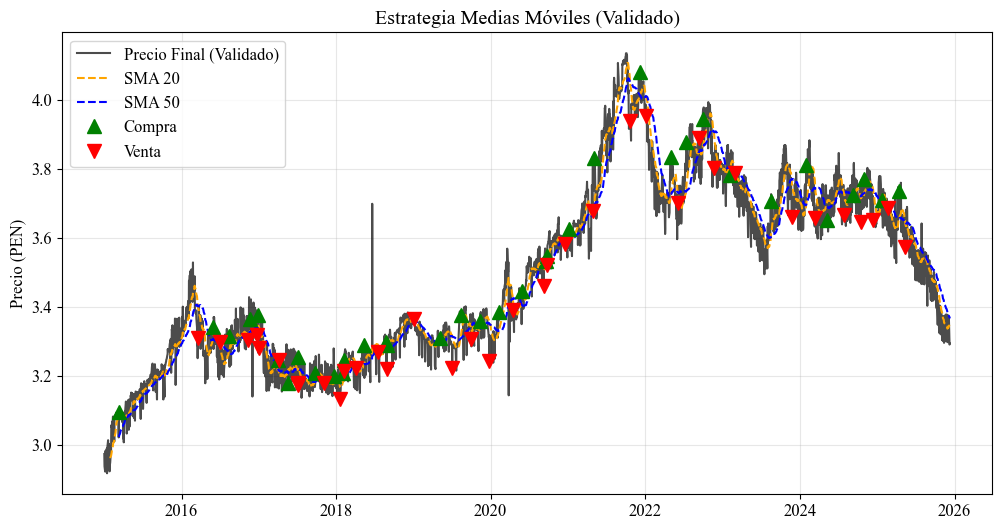

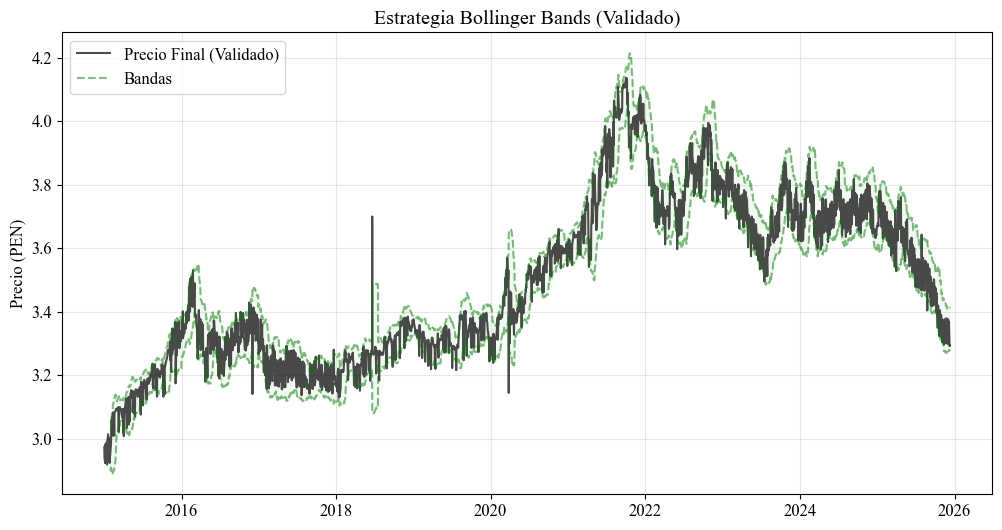

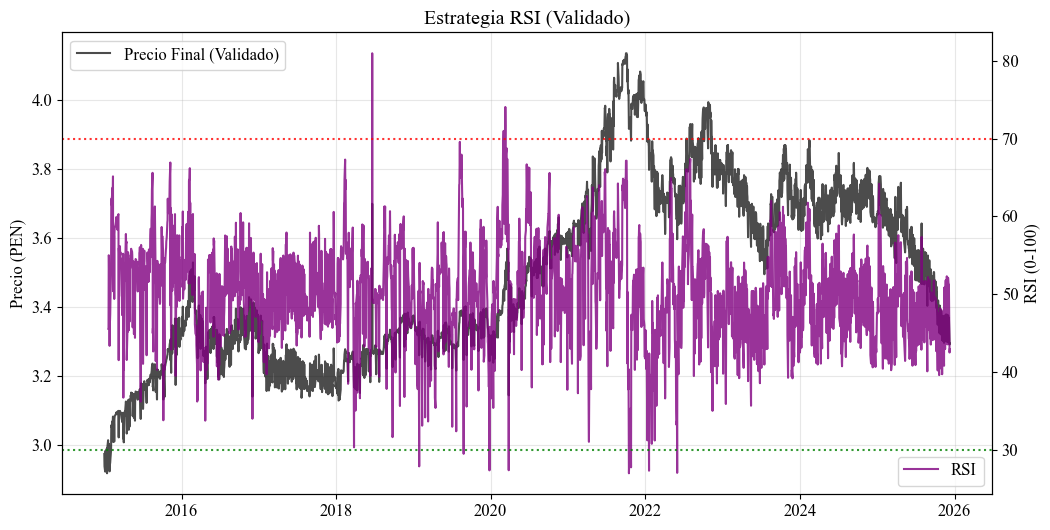

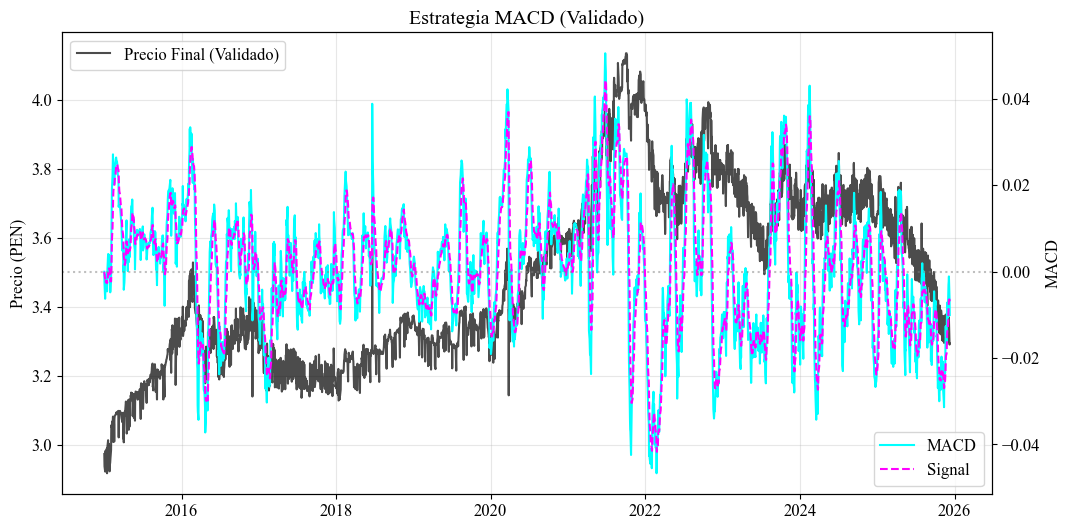


       RESULTADOS DE ESTRATEGIAS (PRECIOS CORRECTOS)
Fecha de Análisis: 2025-12-09
Precio de Cierre Final: 3.2952 PEN

Estrategia                | Estado                              | Señal     
--------------------------------------------------------------------------------
Medias Móviles            | SMA Corta < Larga                   | VENTA     
RSI                       | RSI = 42.90                         | MANTENER  
MACD                      | MACD < Signal                       | VENTA     
Bollinger                 | Neutral                             | MANTENER  
--------------------------------------------------------------------------------
PUNTAJE FINAL: -2.5
RECOMENDACIÓN TÉCNICA: >>> VENTA FUERTE <<<


       MICRO-ANÁLISIS INTRADÍA (HOY)
Último precio (5m): 3.3678
RSI (14 pds): 60.79
Tendencia Corto Plazo: NEUTRAL

Calculando ARIMA...


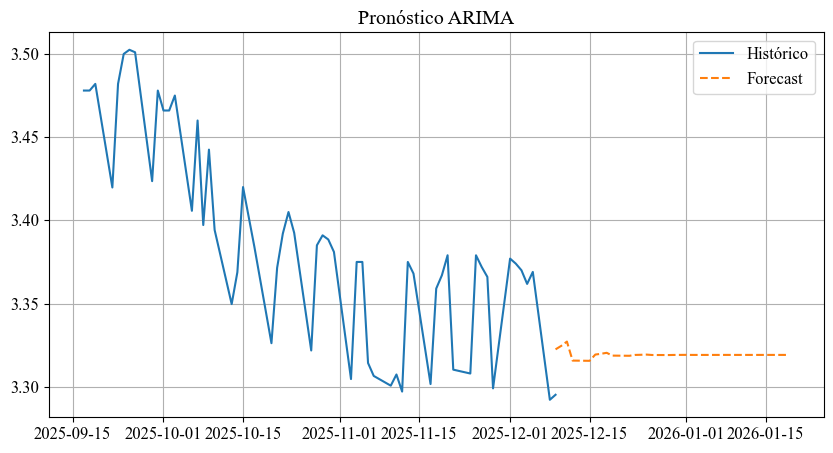

In [6]:
# --- LIBRERÍAS NECESARIAS ---
# pip install yfinance pandas matplotlib statsmodels

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
from datetime import date, timedelta, datetime
import tkinter as tk
from tkinter import simpledialog, messagebox
import json
import os

# --- CONFIGURACIÓN GLOBAL ---
warnings.filterwarnings("ignore")
ARCHIVO_DB = "sbs_historico.json"

# --- GESTIÓN DE PERSISTENCIA ---
def cargar_datos_guardados():
    if not os.path.exists(ARCHIVO_DB): return {}
    try:
        with open(ARCHIVO_DB, 'r') as f:
            data_raw = json.load(f)
            return {datetime.strptime(k, "%Y-%m-%d").date(): v for k, v in data_raw.items()}
    except: return {}

def guardar_datos_nuevos(datos_nuevos):
    datos_actuales = cargar_datos_guardados()
    datos_actuales.update(datos_nuevos)
    datos_json = {k.strftime("%Y-%m-%d"): v for k, v in datos_actuales.items()}
    with open(ARCHIVO_DB, 'w') as f:
        json.dump(datos_json, f, indent=4)

# --- GUI INGRESO MANUAL ---
def ingresar_datos_sbs_manual(lista_fechas):
    resultados_manuales = {}
    root = tk.Tk()
    root.withdraw() 

    ventana = tk.Toplevel(root)
    ventana.title("Actualización Diaria SBS")
    ventana.geometry("420x550")
    ventana.attributes('-topmost', True)

    tk.Label(ventana, text=f"Faltan datos para {len(lista_fechas)} día(s).\nIngresa T.C. VENTA SBS:", font=("Arial", 11, "bold")).pack(pady=10)

    entries = {}
    frame = tk.Frame(ventana)
    frame.pack(fill="both", expand=True, padx=10)
    
    # Ordenar: más reciente arriba
    for fecha in sorted(lista_fechas, reverse=True):
        row = tk.Frame(frame); row.pack(fill="x", pady=3)
        tk.Label(row, text=f"{fecha} ({fecha.strftime('%A')[:3]}):", width=22, anchor="w").pack(side="left")
        ent = tk.Entry(row, width=12); ent.pack(side="right")
        entries[fecha] = ent

    def guardar():
        for f, e in entries.items():
            val = e.get().strip()
            if val:
                try: resultados_manuales[f] = float(val.replace(',', '.'))
                except: pass
        ventana.destroy(); root.destroy()

    tk.Button(ventana, text="GUARDAR DATOS >>", command=guardar, bg="#28a745", fg="white", font=("Arial", 10, "bold")).pack(pady=20)
    ventana.wait_window()
    return resultados_manuales

# --- FUNCIONES DE DATOS ---
def obtener_data_intradia_completa(ticker="PEN=X"):
    print("\n" + "="*85)
    print(" 1. ANÁLISIS PRELIMINAR INTRADÍA (YAHOO)")
    print("="*85)
    end = date.today() + timedelta(days=1)
    start = end - timedelta(days=12)
    data = yf.download(ticker, start=start, end=end, interval="15m", progress=False, auto_adjust=False)
    
    if data.empty: return None, None
    if isinstance(data.columns, pd.MultiIndex): data.columns = data.columns.get_level_values(0)
    data.index = data.index.tz_convert('America/Lima')
    
    cierres = {}
    unique_dates = data.index.normalize().unique().sort_values(ascending=False)
    for d in unique_dates:
        if d.weekday() >= 5: continue
        day_data = data[data.index.date == d.date()]
        if not day_data.empty:
            cierres[d] = day_data.iloc[-1]['Close']
            print(f"Detectado {d.strftime('%Y-%m-%d')}: Yahoo Close = {cierres[d]:.4f}")
            
    return pd.Series(cierres), data

def get_forex_data(ticker, start, end):
    return yf.download(ticker, start=start, end=end, progress=False)

# --- ESTRATEGIAS ---
def moving_average_strategy(data):
    df = data.copy()
    c = df['Close'].iloc[:,0] if isinstance(df['Close'], pd.DataFrame) else df['Close']
    df['SMA_Short'] = c.rolling(20).mean()
    df['SMA_Long'] = c.rolling(50).mean()
    df['Signal'] = 0
    df.loc[df.index[20:], 'Signal'] = (df['SMA_Short'] > df['SMA_Long']).astype(int) * 2 - 1
    df['Position'] = df['Signal'].diff()
    return df

def rsi_strategy(data):
    df = data.copy()
    c = df['Close'].iloc[:,0] if isinstance(df['Close'], pd.DataFrame) else df['Close']
    delta = c.diff(1)
    gain = delta.where(delta > 0, 0); loss = -delta.where(delta < 0, 0)
    avg_gain = gain.ewm(com=13, min_periods=14).mean()
    avg_loss = loss.ewm(com=13, min_periods=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    df['Signal'] = 0; df.loc[df['RSI'] < 30, 'Signal'] = 1; df.loc[df['RSI'] > 70, 'Signal'] = -1
    return df

def macd_strategy(data):
    df = data.copy()
    c = df['Close'].iloc[:,0] if isinstance(df['Close'], pd.DataFrame) else df['Close']
    ema_s = c.ewm(span=12, adjust=False).mean()
    ema_l = c.ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_s - ema_l
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['Signal'] = 0; df.loc[df['MACD'] > df['Signal_Line'], 'Signal'] = 1; df.loc[df['MACD'] < df['Signal_Line'], 'Signal'] = -1
    return df

def bollinger_bands_strategy(data):
    df = data.copy()
    c = df['Close'].iloc[:,0] if isinstance(df['Close'], pd.DataFrame) else df['Close']
    df['SMA_Mid'] = c.rolling(20).mean()
    std = c.rolling(20).std()
    df['Upper_Band'] = df['SMA_Mid'] + (2 * std)
    df['Lower_Band'] = df['SMA_Mid'] - (2 * std)
    df['Signal'] = 0; df.loc[c < df['Lower_Band'], 'Signal'] = 1; df.loc[c > df['Upper_Band'], 'Signal'] = -1
    return df

# --- REPORTE DE RESULTADOS ---
def generate_final_recommendation(strategies, forex_data):
    print("\n" + "="*80); print("       RESULTADOS DE ESTRATEGIAS (PRECIOS CORRECTOS)"); print("="*80)
    c = forex_data['Close'].iloc[:,0] if isinstance(forex_data['Close'], pd.DataFrame) else forex_data['Close']
    
    # Usar el último día válido
    idx = -1
    date_analizada = forex_data.index[idx]
    price = float(c.iloc[idx])
    
    print(f"Fecha de Análisis: {date_analizada.strftime('%Y-%m-%d')}")
    print(f"Precio de Cierre Final: {price:.4f} PEN\n")
    
    print(f"{'Estrategia':<25} | {'Estado':<35} | {'Señal':<10}")
    print("-" * 80)
    
    score = 0
    for name, df in strategies.items():
        if df.empty or 'Signal' not in df: continue
        sig = df['Signal'].iloc[idx]
        
        desc = "Neutral"
        signal_txt = "MANTENER"
        s_val = 0
        
        if name == 'Medias Móviles':
            if sig == 1: desc="SMA Corta > Larga"; signal_txt="COMPRA"; s_val=1
            elif sig == -1: desc="SMA Corta < Larga"; signal_txt="VENTA"; s_val=-1
        elif name == 'RSI':
            rsi_val = df['RSI'].iloc[idx]
            desc = f"RSI = {rsi_val:.2f}"
            if sig == 1: signal_txt="COMPRA"; s_val=1
            elif sig == -1: signal_txt="VENTA"; s_val=-1
        elif name == 'MACD':
            if sig == 1: desc="MACD > Signal"; signal_txt="COMPRA"; s_val=1.5
            elif sig == -1: desc="MACD < Signal"; signal_txt="VENTA"; s_val=-1.5
        elif name == 'Bollinger':
            if sig == 1: desc="Precio < Banda Inf"; signal_txt="COMPRA"; s_val=1
            elif sig == -1: desc="Precio > Banda Sup"; signal_txt="VENTA"; s_val=-1
            
        score += s_val
        print(f"{name:<25} | {desc:<35} | {signal_txt:<10}")
        
    print("-" * 80)
    decision = "NEUTRAL"
    if score >= 2: decision = "COMPRA FUERTE"
    elif score >= 0.5: decision = "COMPRA LEVE"
    elif score <= -2: decision = "VENTA FUERTE"
    elif score <= -0.5: decision = "VENTA LEVE"
    
    print(f"PUNTAJE FINAL: {score}")
    print(f"RECOMENDACIÓN TÉCNICA: >>> {decision} <<<")
    print("="*80 + "\n")

def run_intraday_analysis_now():
    print("\n" + "="*60); print("       MICRO-ANÁLISIS INTRADÍA (HOY)"); print("="*60)
    # Descargar solo el día de hoy, intervalo 5m
    data = yf.download("PEN=X", period="1d", interval="5m", progress=False)
    if data.empty:
        print("Mercado cerrado o sin datos intradía por el momento.")
        return

    if isinstance(data.columns, pd.MultiIndex): data.columns = data.columns.get_level_values(0)
    last_p = data['Close'].iloc[-1]
    print(f"Último precio (5m): {last_p:.4f}")
    
    # Estrategias rápidas
    ma = moving_average_strategy(data)
    rsi = rsi_strategy(data)
    
    # Últimas señales
    s_ma = ma['Signal'].iloc[-1]
    s_rsi = rsi['Signal'].iloc[-1]
    rsi_val = rsi['RSI'].iloc[-1]
    
    print(f"RSI (14 pds): {rsi_val:.2f}")
    
    final_s = "NEUTRAL"
    if s_ma == 1 and s_rsi == 1: final_s = "COMPRA (Momentum Alcista)"
    elif s_ma == -1 and s_rsi == -1: final_s = "VENTA (Momentum Bajista)"
    
    print(f"Tendencia Corto Plazo: {final_s}")
    print("="*60 + "\n")

def plot_strategy(df, title, final_data):
    """
    Función de ploteo restaurada que detecta y dibuja 
    Múltiples indicadores (SMA, RSI, MACD, Bollinger)
    """
    if df.empty: return
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    prices = final_data['Close'].iloc[:, 0] if isinstance(final_data['Close'], pd.DataFrame) else final_data['Close']
    
    # Eje Principal: Precio
    ax1.plot(prices.index, prices.values, label='Precio Final (Validado)', color='black', alpha=0.7)

    # --- Ploteo condicional según indicador ---
    
    # 1. MEDIAS MÓVILES
    if 'SMA_Short' in df.columns:
        ax1.plot(df['SMA_Short'], label='SMA 20', color='orange', linestyle='--')
        ax1.plot(df['SMA_Long'], label='SMA 50', color='blue', linestyle='--')
        # Señales de cruce
        if 'Position' in df.columns:
            buy = df[df['Position'] == 2]
            sell = df[df['Position'] == -2]
            ax1.plot(buy.index, prices.loc[buy.index], '^', color='green', markersize=10, label='Compra')
            ax1.plot(sell.index, prices.loc[sell.index], 'v', color='red', markersize=10, label='Venta')

    # 2. BANDAS DE BOLLINGER
    if 'Upper_Band' in df.columns:
        ax1.plot(df['Upper_Band'], color='green', linestyle='--', alpha=0.5, label='Bandas')
        ax1.plot(df['Lower_Band'], color='green', linestyle='--', alpha=0.5)
        ax1.fill_between(df.index, df['Lower_Band'], df['Upper_Band'], color='green', alpha=0.05)

    ax1.set_title(title)
    ax1.set_ylabel('Precio (PEN)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # --- Ejes Secundarios (TwinX) ---

    # 3. RSI
    if 'RSI' in df.columns:
        ax2 = ax1.twinx()
        ax2.plot(df['RSI'], color='purple', alpha=0.8, label='RSI')
        ax2.axhline(70, color='red', linestyle=':', alpha=0.8)
        ax2.axhline(30, color='green', linestyle=':', alpha=0.8)
        ax2.set_ylabel('RSI (0-100)')
        ax2.legend(loc='lower right')
    
    # 4. MACD
    if 'MACD' in df.columns:
        ax2 = ax1.twinx()
        ax2.plot(df['MACD'], color='cyan', label='MACD')
        ax2.plot(df['Signal_Line'], color='magenta', linestyle='--', label='Signal')
        ax2.axhline(0, color='gray', linestyle=':', alpha=0.5)
        ax2.set_ylabel('MACD')
        ax2.legend(loc='lower right')

    plt.show()

# --- MAIN ---
if __name__ == "__main__":
    TICKER = "PEN=X"
    
    # 1. Descargas
    cierres_yahoo, full_intraday_data = obtener_data_intradia_completa(TICKER)
    print(f"Descargando histórico diario...")
    forex_data = get_forex_data(TICKER, "2015-01-01", date.today().strftime("%Y-%m-%d"))

    # 2. Sync inicial
    if cierres_yahoo is not None:
        cierres_yahoo.index = cierres_yahoo.index.tz_localize(None)
        col = forex_data['Close']
        if isinstance(col, pd.DataFrame): forex_data['Close'].iloc[:,0].update(cierres_yahoo)
        else: forex_data['Close'].update(cierres_yahoo)

    # 3. VALIDACIÓN HÍBRIDA (JUEZ DE HIERRO + MEMORIA)
    if cierres_yahoo is not None:
        # Fechas hábiles anteriores a hoy
        fechas_requeridas = [d.date() for d in cierres_yahoo.index if d.date() < date.today() and d.weekday() < 5]
        
        # Memoria
        datos_guardados = cargar_datos_guardados()
        fechas_faltantes = [f for f in fechas_requeridas if f not in datos_guardados]
        
        if fechas_faltantes:
            print(f"\n[AVISO] Faltan datos para {len(fechas_faltantes)} fechas. Abriendo ventana manual...")
            nuevos = ingresar_datos_sbs_manual(fechas_faltantes)
            guardar_datos_nuevos(nuevos)
            datos_guardados.update(nuevos)
        
        print("\n" + "*"*100)
        print(f"{'REPORTE DE VALIDACIÓN (TOLERANCIA: 0.05%)':^100}")
        print(f"{'Fecha':<12} | {'Yahoo':<10} | {'SBS':<10} | {'Diff %':<9} | {'Acción Realizada'}")
        print("-" * 100)
        
        for fecha in fechas_requeridas:
            match = [ts for ts in cierres_yahoo.index if ts.date() == fecha]
            if not match: continue
            p_yahoo = float(cierres_yahoo[match[0]])
            p_sbs = datos_guardados.get(fecha)
            
            p_final = p_yahoo
            
            if p_sbs:
                diff = abs(p_yahoo - p_sbs) / p_sbs * 100
                if diff < 0.05:
                    msg = "✅ OK (Yahoo)"
                else:
                    # Búsqueda inteligente intradía
                    day_data = full_intraday_data[full_intraday_data.index.date == fecha].sort_index(ascending=False)
                    found = None
                    for idx, row in day_data.iterrows():
                        p_intra = float(row['Close'])
                        if abs(p_intra - p_sbs)/p_sbs*100 < 0.05:
                            found = p_intra; break
                    
                    if found:
                        p_final = found
                        msg = "🔍 CORREGIDO (Intradía Yahoo)"
                    else:
                        p_final = p_sbs
                        msg = "⚠️ FALLBACK SBS"
                    
                    # Aplicar corrección
                    ts_idx = pd.Timestamp(fecha)
                    if ts_idx in forex_data.index:
                        if isinstance(forex_data['Close'], pd.DataFrame): forex_data.loc[ts_idx, ('Close', TICKER)] = p_final
                        else: forex_data.loc[ts_idx, 'Close'] = p_final
                
                print(f"{fecha:<12} | {p_yahoo:<10.4f} | {p_sbs:<10.4f} | {diff:<8.3f}% | {msg} -> {p_final:.4f}")
            else:
                print(f"{fecha:<12} | {p_yahoo:<10.4f} | {'---':<10} | {'---':<9} | ℹ️ Sin dato SBS")
        print("*"*100 + "\n")

    # 4. CÁLCULO DE ESTRATEGIAS
    strategies = {
        'Medias Móviles': moving_average_strategy(forex_data),
        'RSI': rsi_strategy(forex_data),
        'MACD': macd_strategy(forex_data),
        'Bollinger': bollinger_bands_strategy(forex_data)
    }

    # 5. VISUALIZACIÓN (TODOS LOS GRÁFICOS)
    print("Generando gráficos... (puedes cerrar las ventanas para continuar)")
    plot_strategy(strategies['Medias Móviles'], "Estrategia Medias Móviles (Validado)", forex_data)
    plot_strategy(strategies['Bollinger'], "Estrategia Bollinger Bands (Validado)", forex_data)
    plot_strategy(strategies['RSI'], "Estrategia RSI (Validado)", forex_data)
    plot_strategy(strategies['MACD'], "Estrategia MACD (Validado)", forex_data)

    # 6. TABLA DE RESULTADOS FINAL
    generate_final_recommendation(strategies, forex_data)

    # 7. ANÁLISIS INTRADÍA (Micro)
    run_intraday_analysis_now()

    # 8. ARIMA
    print("Calculando ARIMA...")
    s = forex_data['Close'].iloc[:,0] if isinstance(forex_data['Close'], pd.DataFrame) else forex_data['Close']
    mod = ARIMA(s.dropna(), order=(5,1,0)).fit()
    fc = mod.get_forecast(30).predicted_mean
    plt.figure(figsize=(10,5))
    plt.plot(s.index[-60:], s.iloc[-60:], label="Histórico"); plt.plot(pd.date_range(s.index[-1], periods=30, freq='B'), fc, '--', label="Forecast")
    plt.title("Pronóstico ARIMA"); plt.legend(); plt.grid(); plt.show()

In [5]:
# ==============================================================================
#  CELDA FINAL: GRÁFICO APA + TABLA ESTILO LATEX (FUENTE BCRP)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import requests
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# --- CONFIGURACIÓN DE ESTILO "LATEX / APA" ---
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["font.size"] = 12

def obtener_data_bcrp():
    """
    Descarga la serie PN01218PM (Tipo de Cambio Bancario Venta - Fin de Periodo)
    directamente de la API del BCRP.
    """
    print("⏳ Conectando con API del BCRP...")
    # Solicitamos data hasta un futuro (2026) para asegurar traer el presente
    url = "https://estadisticas.bcrp.gob.pe/estadisticas/series/api/PN01218PM/json/2023-1/2026-12"
    
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data_json = response.json()
        periodos = data_json.get('periods', [])
        
        fechas = []
        valores = []
        meses_map = {
            'Ene': '01', 'Feb': '02', 'Mar': '03', 'Abr': '04', 'May': '05', 'Jun': '06',
            'Jul': '07', 'Ago': '08', 'Sep': '09', 'Set': '09', 'Oct': '10', 'Nov': '11', 'Dic': '12'
        }
        
        for p in periodos:
            txt_fecha = p['name'] # Ej: "Sep.2024"
            val_str = p['values'][0]
            try:
                mes_txt, anio = txt_fecha.split('.')
                mes_num = meses_map.get(mes_txt, '01')
                # Forzamos fin de mes
                fecha_dt = pd.to_datetime(f"{anio}-{mes_num}-01") + pd.offsets.MonthEnd(0)
                fechas.append(fecha_dt)
                valores.append(float(val_str))
            except: continue
                
        df = pd.DataFrame({'Date': fechas, 'BCRP_Oficial': valores})
        df.set_index('Date', inplace=True)
        return df
    except Exception as e:
        print(f"⚠️ Error BCRP: {e}")
        return pd.DataFrame()

def renderizar_tabla_latex(df):
    """
    Dibuja un DataFrame como una tabla gráfica con estilo académico (LaTeX).
    CORREGIDO: Ajuste de márgenes para evitar superposición de la fuente.
    """
    # Preparamos el texto
    df_plot = df.copy()
    df_plot.index = df_plot.index.strftime('%b-%Y') 
    
    # Redondear y rellenar nulos
    df_plot = df_plot.applymap(lambda x: f"{x:.4f}" if pd.notnull(x) else "-")
    df_plot.columns = ['Yahoo (Mercado)', 'BCRP (Oficial)', 'Diferencia']

    # Crear figura
    # Aumentamos un poco el alto base para dar "aire"
    fig, ax = plt.subplots(figsize=(8, len(df_plot)*0.4 + 1.2)) 
    ax.axis('off')
    
    # Crear la tabla
    tabla = ax.table(
        cellText=df_plot.values,
        colLabels=df_plot.columns,
        rowLabels=df_plot.index,
        loc='center',
        cellLoc='center',
        bbox=[0, 0, 1, 1]
    )
    
    # --- ESTILIZAR LA TABLA ---
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(11)
    
    for (row, col), cell in tabla.get_celld().items():
        cell.set_edgecolor('black')
        cell.set_linewidth(0.5)
        cell.set_height(0.06)
        
        if row == 0: # Encabezado
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#333333')
            cell.set_linewidth(1.5)
        elif col == -1: # Índice (Fechas)
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f2f2f2')
            
    ax.set_title("Tabla 1. Comparativa de Precios de Cierre", 
                 pad=20, weight='bold', loc='left')
    
    # --- CORRECCIÓN DE LA NOTA AL PIE ---
    # 1. Colocamos el texto
    plt.figtext(0.01, 0.02, "Fuente: Elaboración propia con datos de BCRP y Yahoo Finance.", 
                fontsize=9, style='italic', ha='left')
    
    # 2. IMPORTANTE: Reservamos el 6% inferior de la figura para que la tabla no baje tanto
    # rect = [left, bottom, right, top]
    plt.tight_layout(rect=[0, 0.02, 1, 1])
    
    plt.show()

def reporte_bonito_completo(forex_data):
    # 1. Preparar Datos
    yahoo = forex_data['Close']
    if isinstance(yahoo, pd.DataFrame): yahoo = yahoo.iloc[:, 0]
    
    y_m = yahoo.resample('M').last()
    y_m = y_m[y_m.index >= '2023-01-01']
    
    bcrp = obtener_data_bcrp() # Data BCRP
    
    # Merge
    df = pd.DataFrame({'Yahoo': y_m}).join(bcrp, how='outer')
    df = df[df.index >= '2023-01-01'].dropna(how='all').sort_index(ascending=False) # Ordenar reciente arriba
    
    # Calcular diferencia
    df['Diff'] = df['Yahoo'] - df['BCRP_Oficial']

    # 2. GRÁFICO DE LÍNEAS (ARRIBA)
    plt.figure(figsize=(10, 5))
    
    # Ploteamos cronológicamente (invertimos el DF para el gráfico)
    df_graph = df.sort_index() 
    
    plt.plot(df_graph.index, df_graph['Yahoo'], '-o', color='black', alpha=0.7, label='Yahoo Finance', markersize=4)
    plt.plot(df_graph.index, df_graph['BCRP_Oficial'], '--s', color='#003366', linewidth=1.5, label='BCRP (Oficial)', markersize=4)
    
    plt.title("Figura 1. Evolución del Tipo de Cambio: BCRP vs Mercado", loc='left', pad=15)
    plt.ylabel("Soles (PEN)")
    plt.legend(frameon=False)
    plt.grid(True, alpha=0.2, linestyle=':')
    
    # Quitamos bordes feos
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    # 3. TABLA BONITA (ABAJO)
    renderizar_tabla_latex(df)

# --- EJECUCIÓN ---
if 'forex_data' in globals():
    reporte_bonito_completo(forex_data)
else:
    print("⚠️ Falta 'forex_data'. Corre la celda principal primero.")

⚠️ Falta 'forex_data'. Corre la celda principal primero.
